In [1]:
pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 61.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
#libraries
import spacy
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from transformers import pipeline
from collections import defaultdict

**Load a Dickens Text**

In [3]:
# our mutual friend
url = "https://www.gutenberg.org/cache/epub/883/pg883.txt"
text = requests.get(url).text

**Preprocess & Load into spaCy**

In [4]:
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 9000000000000000000

doc = nlp(text[3000:])

**Extract Sentences with Mental State Verbs**

In [5]:
theory_of_mind_verbs = [
    "think", "believe", "know", "wonder", "suppose", "realize",
    "realise","imagine", "guess", "doubt", "feel", "consider",
    "hope","wish", "suspect", "predict", "expect", "assume", "fear"
]

matching_sentences = []

for sent in doc.sents:
    if any(token.lemma_ in theory_of_mind_verbs for token in sent):
        matching_sentences.append(sent.text)

**Count Mental State Verb Frequency**

In [6]:
verb_counts = Counter()

for sent in doc.sents:
    for token in sent:
        if token.lemma_ in theory_of_mind_verbs:
            verb_counts[token.lemma_] += 1

print(verb_counts.most_common())

[('know', 1101), ('think', 732), ('feel', 220), ('hope', 218), ('suppose', 183), ('wish', 176), ('believe', 144), ('consider', 112), ('expect', 88), ('doubt', 88), ('wonder', 71), ('fear', 36), ('suspect', 30), ('guess', 21), ('assume', 17), ('imagine', 15), ('realize', 3), ('predict', 3)]


**Visualise Frequency Over Time (Chunk-Based)**

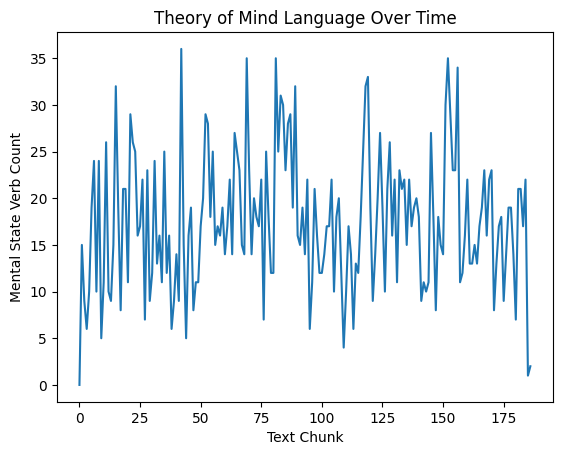

In [7]:
chunk_size = 10000  # adjustments can be made
chunks = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
counts_over_time = []

for chunk in chunks:
    doc = nlp(chunk)
    count = sum(1 for token in doc if token.lemma_ in theory_of_mind_verbs)
    counts_over_time.append(count)

plt.plot(counts_over_time)
plt.xlabel("Text Chunk")
plt.ylabel("Mental State Verb Count")
plt.title("Theory of Mind Language Over Time")
plt.show()

**Track Character Co-occurrence**
To find which characters are associated with mental states.

In [8]:
characters = [
    "John Harmon", "John Rokesmith", "Handford", "Mr. Rokesmith",
    "Bella Wilfer", "Bella", "Miss Wilfer", "Mrs. John Harmon",
    "Lizzie Hexam", "Lizzie", "Miss Hexam",
    "Gaffer Hexam", "Hexam", "Mr. Hexam", "the waterman",
    "Mr. Mortimer Lightwood", "Mortimer", "Mr. Lightwood",
    "Eugene Wrayburn", "Wrayburn", "Mr. Wrayburn", "Eugene",
    "Mr. Boffin", "Noddy Boffin", "The Golden Dustman",
    "Mrs. Boffin", "Mrs. B.", "The old lady",
    "Silas Wegg", "Mr. Wegg", "Wegg",
    "Mr. Venus", "Venus", "the articulator",
    "Jenny Wren", "Fanny Cleaver", "Miss Wren", "The doll's dressmaker",
    "Rogue Riderhood", "Riderhood", "Mr. Riderhood", "the lock-keeper",
    "Bradley Headstone", "Headstone", "Mr. Headstone",
    "Charley Hexam", "Charley", "Mr. Hexam", "Charles Hexam",
    "Mr. Wilfer", "Reginald Wilfer", "Father Wilfer",
    "Mrs. Wilfer", "Mrs. W.",
    "Lavinia Wilfer", "Lavinia", "Lavy",
    "George Sampson", "Mr. Sampson",
    "Mr. Twemlow", "Twemlow",
    "Lady Tippins",
    "Podsnap", "Mr. Podsnap", "John Podsnap",
    "Mrs. Podsnap",
    "Georgiana Podsnap", "Miss Podsnap",
    "Fascination Fledgeby", "Fledgeby", "Mr. Fledgeby",
    "Mr. Riah", "Riah",
    "Alfred Lammle", "Mr. Lammle",
    "Sophronia Lammle", "Mrs. Lammle",
    "Miss Abbey Potterson", "Miss Abbey",
    "Pleasant Riderhood", "Pleasant",
    "Sloppy",
    "Miss Peacher", "Peacher",
    "Mr. Dolls", "Dolls", "the drunken man",
    "Venus's friend",
    "The Secretary",  # refers to John Rokesmith alias
    "The Dustman",  # refers to Boffin
    "The Jew",  # used to refer to Riah (problematic language)
    "The Doll's Dressmaker",  # Jenny Wren
    "The Lock-keeper",  # Riderhood
    "The Schoolmaster",  # Bradley Headstone
    "The Lawyer",  # Mortimer Lightwood
]



character_mentalization = {name: 0 for name in characters}

for sent in matching_sentences:
    for name in characters:
        if name in sent:
            character_mentalization[name] += 1

print(character_mentalization)

{'John Harmon': 19, 'John Rokesmith': 10, 'Handford': 6, 'Mr. Rokesmith': 0, 'Bella Wilfer': 3, 'Bella': 193, 'Miss Wilfer': 15, 'Mrs. John Harmon': 0, 'Lizzie Hexam': 9, 'Lizzie': 61, 'Miss Hexam': 0, 'Gaffer Hexam': 1, 'Hexam': 23, 'Mr. Hexam': 0, 'the waterman': 0, 'Mr. Mortimer Lightwood': 0, 'Mortimer': 35, 'Mr. Lightwood': 0, 'Eugene Wrayburn': 5, 'Wrayburn': 33, 'Mr. Wrayburn': 0, 'Eugene': 75, 'Mr. Boffin': 0, 'Noddy Boffin': 0, 'The Golden Dustman': 0, 'Mrs. Boffin': 0, 'Mrs. B.': 0, 'The old lady': 0, 'Silas Wegg': 5, 'Mr. Wegg': 0, 'Wegg': 103, 'Mr. Venus': 0, 'Venus': 60, 'the articulator': 0, 'Jenny Wren': 1, 'Fanny Cleaver': 0, 'Miss Wren': 25, "The doll's dressmaker": 0, 'Rogue Riderhood': 5, 'Riderhood': 58, 'Mr. Riderhood': 0, 'the lock-keeper': 0, 'Bradley Headstone': 7, 'Headstone': 30, 'Mr. Headstone': 0, 'Charley Hexam': 1, 'Charley': 26, 'Charles Hexam': 0, 'Mr. Wilfer': 0, 'Reginald Wilfer': 0, 'Father Wilfer': 0, 'Mrs. Wilfer': 0, 'Mrs. W.': 0, 'Lavinia Wilfer':



---



**BERT-Based Emotion Detection**

**Load Pretrained Emotion Model**

In [9]:
# load emotion classifier pipeline
emotion_pipeline = pipeline("text-classification",
                            model="j-hartmann/emotion-english-distilroberta-base",
                            return_all_scores=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


**Run Emotion Detection on the Whole Book**

In [10]:
def chunk_text(text, size=1000):
    words = text.split()
    return [' '.join(words[i:i+size]) for i in range(0, len(words), size)]

chunks = chunk_text(text[3000:], size=20000)

emotion_scores = []

for chunk in chunks:
    try:
        scores = emotion_pipeline(chunk[:512])[0]  # limit to BERT's max token count
        scores_dict = {s["label"]: s["score"] for s in scores}
        emotion_scores.append(scores_dict)
    except:
        continue

**Convert to DataFrame & Plot Emotion Arcs**

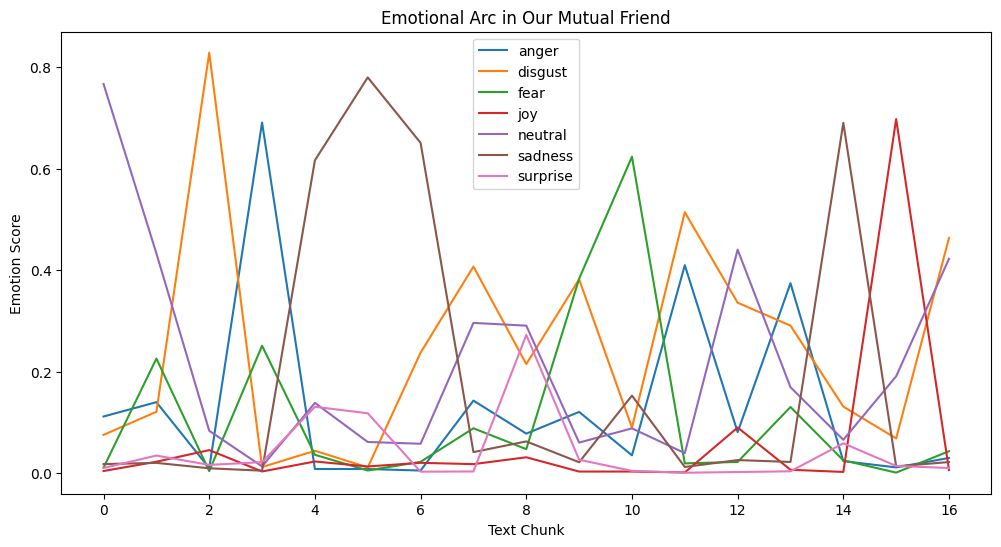

In [11]:
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

plt.figure(figsize=(12, 6))
for emotion in df.columns:
    plt.plot(df[emotion], label=emotion)

plt.legend()
plt.title("Emotional Arc in Our Mutual Friend")
plt.xlabel("Text Chunk")
plt.ylabel("Emotion Score")
plt.show()

Total Emotions

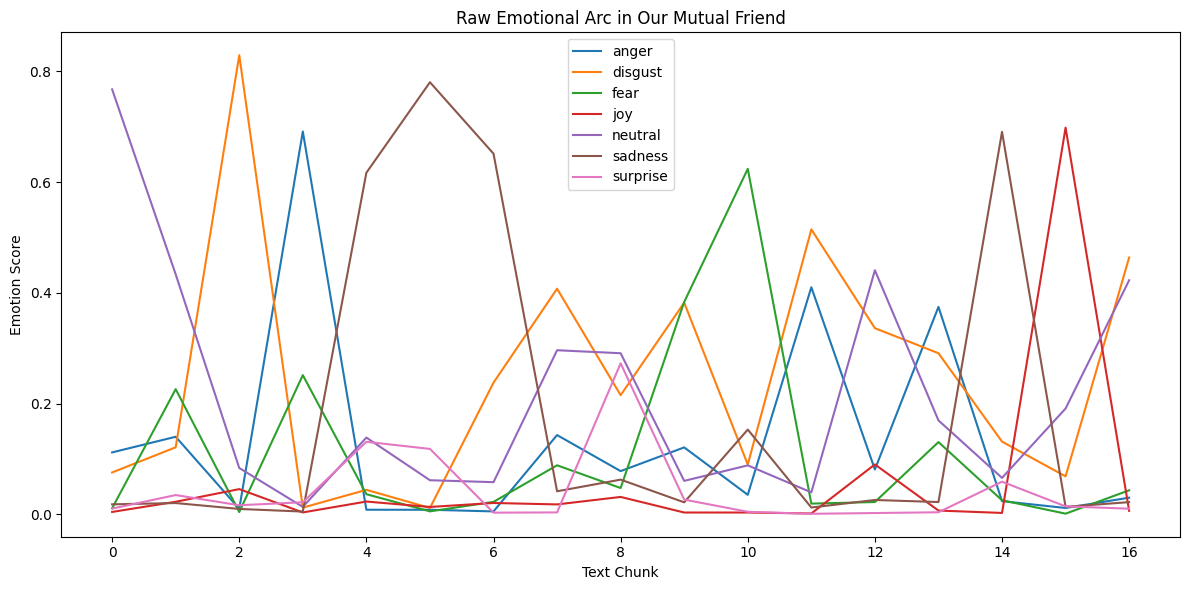

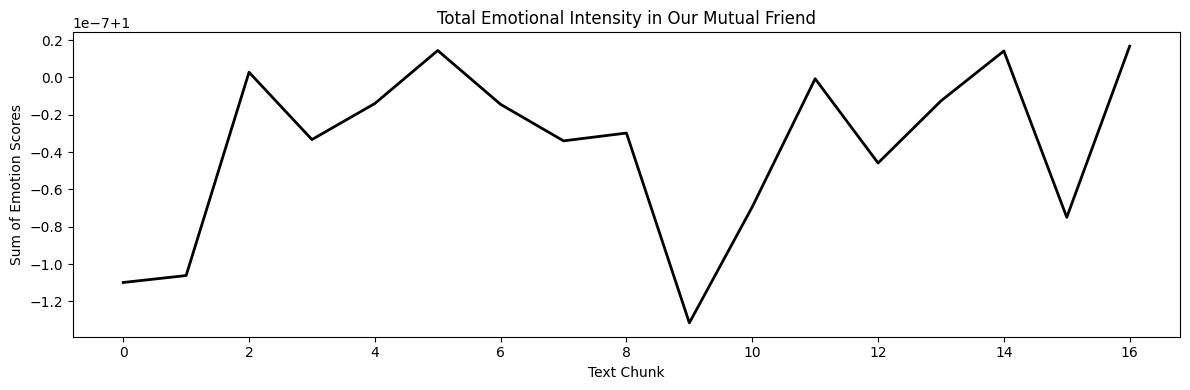

In [12]:
# Analyze emotions in each chunk WITHOUT normalization
emotion_scores = []
for chunk in chunks:
    try:
        scores = emotion_pipeline(chunk[:512])[0]  # limit to BERT's max token count
        score_dict = {s["label"]: s["score"] for s in scores}
        emotion_scores.append(score_dict)
    except Exception as e:
        print(f"Error: {e}")
        continue

# Convert to DataFrame
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

# Plot individual emotions
plt.figure(figsize=(12, 6))
for emotion in df.columns:
    plt.plot(df[emotion], label=emotion)
plt.legend()
plt.title("Raw Emotional Arc in Our Mutual Friend")
plt.xlabel("Text Chunk")
plt.ylabel("Emotion Score")
plt.tight_layout()
plt.show()

# ➕ Now sum all raw emotions at each chunk
df["Total_Emotion"] = df.sum(axis=1)

# Plot total emotional intensity
plt.figure(figsize=(12, 4))
plt.plot(df["Total_Emotion"], color="black", linewidth=2)
plt.title("Total Emotional Intensity in Our Mutual Friend")
plt.xlabel("Text Chunk")
plt.ylabel("Sum of Emotion Scores")
plt.tight_layout()
plt.show()

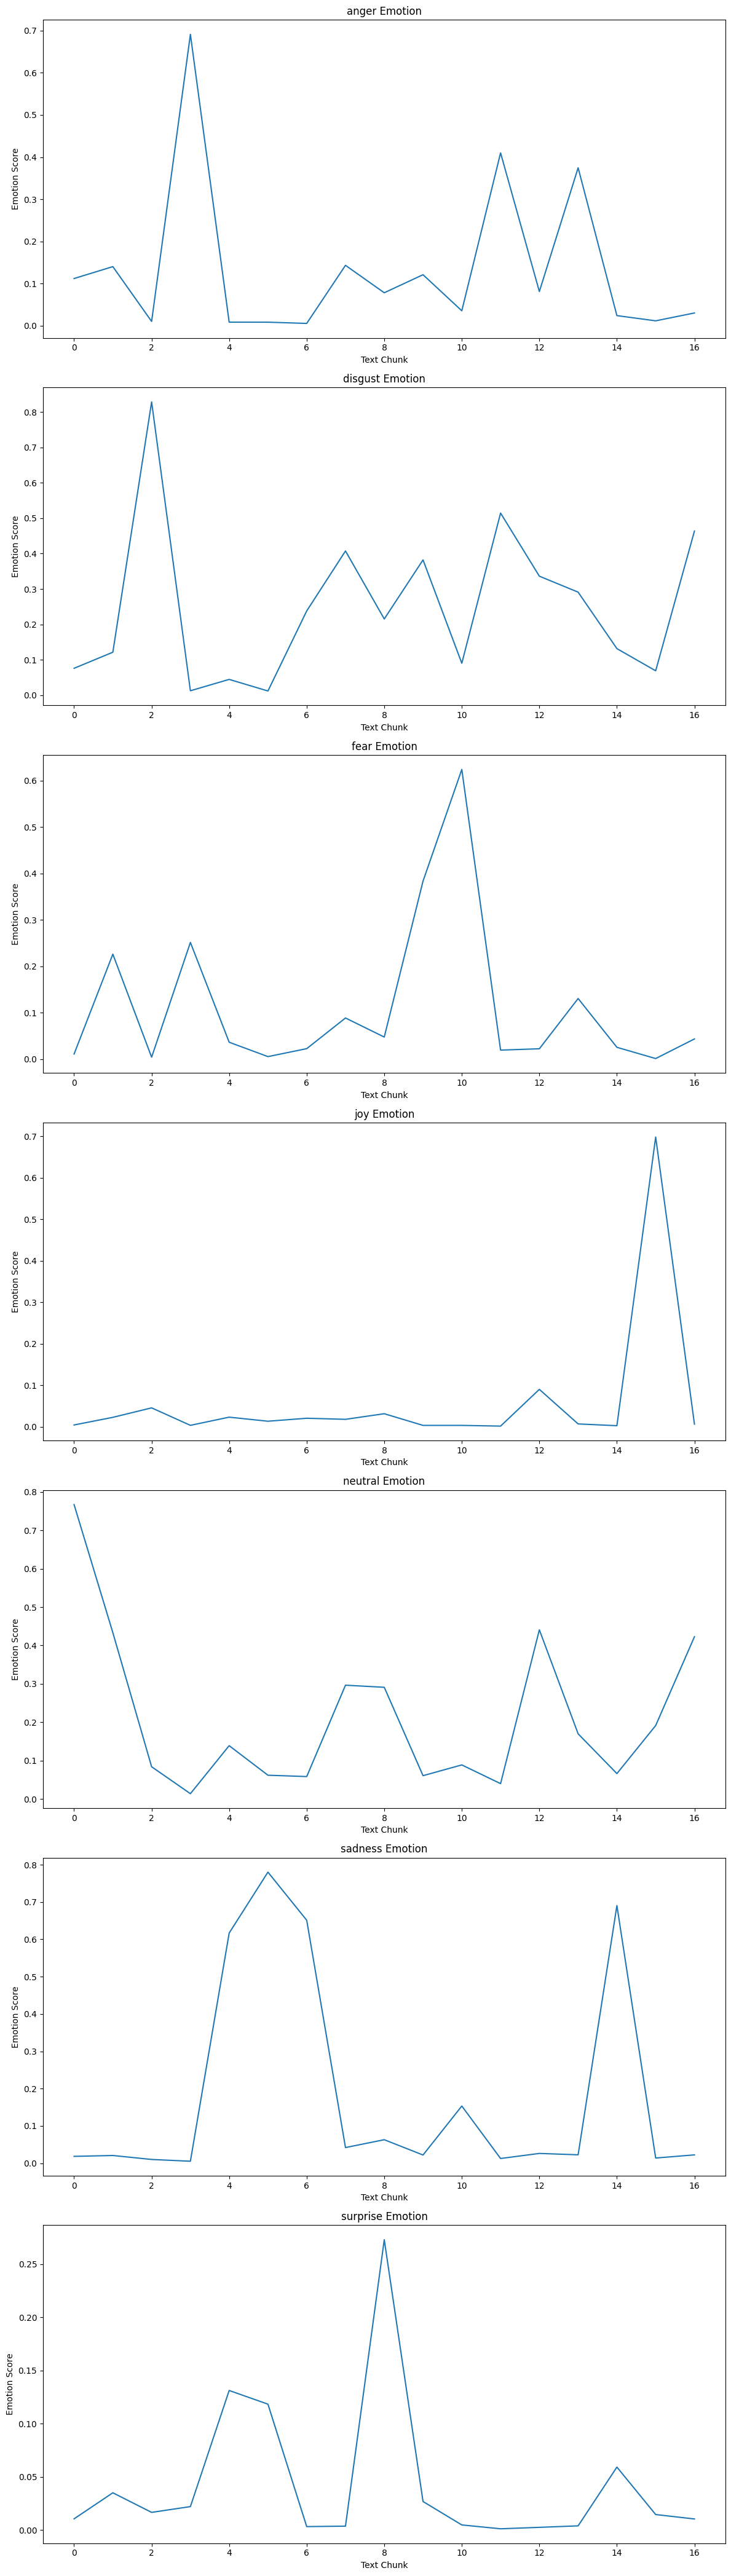

In [13]:
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

# Determine the number of emotions
num_emotions = len(df.columns)

# Set up subplots: one for each emotion
fig, axes = plt.subplots(num_emotions, 1, figsize=(12, 6 * num_emotions))

# If there's only one emotion, axes is not an array, so we handle it separately
if num_emotions == 1:
    axes = [axes]

for i, emotion in enumerate(df.columns):
    axes[i].plot(df[emotion])
    axes[i].set_title(f"{emotion} Emotion")
    axes[i].set_xlabel("Text Chunk")
    axes[i].set_ylabel("Emotion Score")

plt.tight_layout()
plt.show()